# Introduction

## How should I invest £1000?
This project compares ETFs and individual stocks using historical market data. The aim is to investigate how a beginner investor might allocate £1000 between ETFs and individual stocks.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## Data Collection

In [8]:
tickers = ["VUAG.L", "EQGB.L", "MSFT", "NVDA", "GOOGL"]

data = yf.download(
    tickers,
    period="5y",
    auto_adjust=True
)

close = data["Close"]

close.head()

[*********************100%***********************]  5 of 5 completed


Ticker,EQGB.L,GOOGL,MSFT,NVDA,VUAG.L
Date,,,,,
2021-06-14,27503.5,121.369301,249.415619,17.956638,54.654999
2021-06-15,27570.0,120.352295,247.947235,17.727182,54.814999
2021-06-16,27572.5,119.710999,247.006760,17.748859,54.799999
2021-06-17,27787.5,120.673470,250.384827,18.592939,55.169998
2021-06-18,27502.5,119.055313,248.974106,18.574505,55.029999


## Data Overview

In [9]:
close.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1288 entries, 2021-06-14 to 2026-06-12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EQGB.L  1262 non-null   float64
 1   GOOGL   1256 non-null   float64
 2   MSFT    1256 non-null   float64
 3   NVDA    1256 non-null   float64
 4   VUAG.L  1260 non-null   float64
dtypes: float64(5)
memory usage: 60.4 KB


In [10]:
close = close.dropna()

close.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1228 entries, 2021-06-14 to 2026-06-12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EQGB.L  1228 non-null   float64
 1   GOOGL   1228 non-null   float64
 2   MSFT    1228 non-null   float64
 3   NVDA    1228 non-null   float64
 4   VUAG.L  1228 non-null   float64
dtypes: float64(5)
memory usage: 57.6 KB


In [11]:
close.tail()

Ticker,EQGB.L,GOOGL,MSFT,NVDA,VUAG.L
Date,,,,,
2026-06-08,55970.0,363.309998,411.739990,208.639999,107.599998
2026-06-09,54580.0,364.260010,403.410004,208.190002,105.599998
2026-06-10,54460.0,356.380005,397.359985,200.419998,105.540001
2026-06-11,54570.0,357.769989,390.339996,204.869995,105.459999
2026-06-12,56230.0,359.679993,390.739990,205.190002,107.019997


## Historical Performance

In [12]:
normalised = close / close.iloc[0] * 1000

normalised.head()

Ticker,EQGB.L,GOOGL,MSFT,NVDA,VUAG.L
Date,,,,,
2021-06-14,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
2021-06-15,1002.417874,991.620567,994.112703,987.221665,1002.927451
2021-06-16,1002.508772,986.336724,990.341987,988.428851,1002.653014
2021-06-17,1010.325959,994.266826,1003.885914,1035.435421,1009.422732
2021-06-18,999.963641,980.934324,998.229810,1034.408808,1006.861221


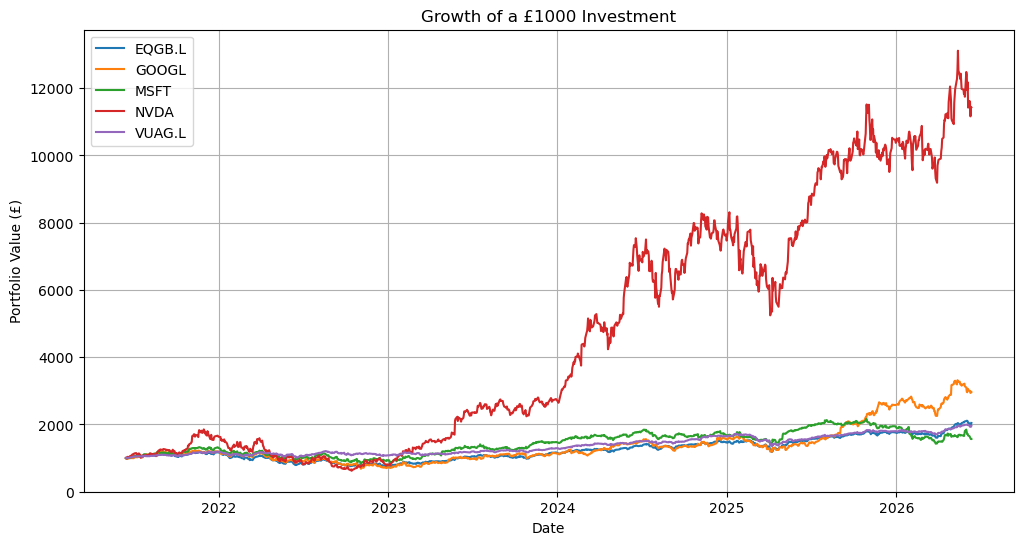

In [13]:
plt.figure(figsize=(12,6))

for ticker in normalised.columns:
    plt.plot(
        normalised.index,
        normalised[ticker],
        label=ticker
    )

plt.title("Growth of a £1000 Investment")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (£)")
plt.legend()

plt.grid(True)

plt.show()

In [14]:
normalised.iloc[-1]

Ticker
EQGB.L     2044.467068
GOOGL      2963.517052
MSFT       1566.621978
NVDA      11426.971942
VUAG.L     1958.100797
Name: 2026-06-12 00:00:00, dtype: float64

## Risk and Return Analysis

In [15]:
total_return = (close.iloc[-1] / close.iloc[0] - 1) * 100

print(total_return)

Ticker
EQGB.L     104.446707
GOOGL      196.351705
MSFT        56.662198
NVDA      1042.697194
VUAG.L      95.810080
dtype: float64


In [16]:
years = len(close) / 252

cagr = (close.iloc[-1] / close.iloc[0]) ** (1 / years) - 1

cagr = cagr * 100

print(cagr)

Ticker
EQGB.L    15.806966
GOOGL     24.974215
MSFT       9.650078
NVDA      64.854148
VUAG.L    14.785749
dtype: float64


## Volatility Analysis

In [17]:
returns = close.pct_change().dropna()

volatility = returns.std() * np.sqrt(252) * 100

print(volatility)

Ticker
EQGB.L    21.271796
GOOGL     31.719743
MSFT      26.929918
NVDA      52.117366
VUAG.L    14.515493
dtype: float64


## Maximum Drawdown

In [18]:
running_max = close.cummax()

drawdown = (close - running_max) / running_max

max_drawdown = drawdown.min() * 100

print(max_drawdown)

Ticker
EQGB.L   -36.774293
GOOGL    -44.320048
MSFT     -37.148486
NVDA     -66.335094
VUAG.L   -20.879586
dtype: float64


## Sharpe Ratio

In [19]:
risk_free_rate = 0.04

cagr_decimal = cagr / 100
vol_decimal = volatility / 100

sharpe = (cagr_decimal - risk_free_rate) / vol_decimal

print(sharpe)

Ticker
EQGB.L    0.555053
GOOGL     0.661235
MSFT      0.209807
NVDA      1.167637
VUAG.L    0.743051
dtype: float64


In [20]:
summary = pd.DataFrame({
    "Total Return (%)": total_return,
    "CAGR (%)": cagr,
    "Volatility (%)": volatility,
    "Max Drawdown (%)": max_drawdown,
    "Sharpe Ratio": sharpe
})

summary.round(2)

,Total Return (%),CAGR (%),Volatility (%),Max Drawdown (%),Sharpe Ratio
Ticker,,,,,
EQGB.L,104.45,15.81,21.27,-36.77,0.56
GOOGL,196.35,24.97,31.72,-44.32,0.66
MSFT,56.66,9.65,26.93,-37.15,0.21
NVDA,1042.70,64.85,52.12,-66.34,1.17
VUAG.L,95.81,14.79,14.52,-20.88,0.74


## Correlation Analysis

In [21]:
correlation = returns.corr()

correlation.round(2)

Ticker,EQGB.L,GOOGL,MSFT,NVDA,VUAG.L
Ticker,,,,,
EQGB.L,1.00,0.44,0.47,0.50,0.81
GOOGL,0.44,1.00,0.58,0.51,0.32
MSFT,0.47,0.58,1.00,0.60,0.35
NVDA,0.50,0.51,0.60,1.00,0.37
VUAG.L,0.81,0.32,0.35,0.37,1.00


## Conclusion

Based on the historical analysis, NVIDIA generated the highest cumulative return but exhibited substantially higher volatility and maximum drawdown.

Google provided a stronger balance between risk and return, while the ETF portfolio (VUAG and EQGB) delivered more stable long-term performance.

Therefore, for a beginner investing £1000, allocating the majority of capital to diversified ETFs and a smaller proportion to selected growth stocks provides a more balanced investment strategy.

Recommended Portfolio

- 50% VUAG
- 20% EQGB
- 15% NVIDIA
- 15% Google